[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nhouba/slotflow-esa-workshop/blob/main/slotflow_tutorial_2_solution.ipynb)

# Tutorial 2 (SOLUTION) — Diagnosing SlotFlow, a pretrained trans-dimensional model

This session uses the **pretrained SlotFlow** model (Houba, Giarda &
Speri, arXiv:2511.23228) trained on LISA-like sinusoid mixtures with an
*unknown number of sources* K ∈ {1…10}. No training here — we analyse and
debug, the way you would qualify any inference component for a pipeline.

**One thing to be clear about up front: the network does not run in any of
the analysis cells below.** It was run *offline* on 2,000 test signals —
1,200 **nominal** (drawn from the same distribution the model was trained
on) and 800 **stress**: frequencies packed to a minimum separation of
4 mHz where training never went below 10 mHz, and noise drawn from
1.0–2.0 where training drew 0–1.5. So the separation is strictly outside
the training range and the noise reaches above it; that is where the
failures we study live. Plus controlled
stability experiments. Everything
it produced — the cardinality posterior q(K|x), each slot's MAP
parameters, posterior samples and widths, embeddings, the input spectra,
and the true catalogues — is stored in a **prediction pack** that every
cell below reads from. In code that pack is a plain Python dictionary
called `pack`: the keys are names like `stress_maps` or `stress_spec`, and
the values are numpy arrays with one entry per test signal. That is why the
notebook is fast and CPU-only.
Appendix **A0** shows how to run the pretrained model yourself.

| when | what |
|---|---|
| 0–4′ | setup |
| 4–10′ | **§1** bridge from the toy; q(K\|x) and the count; meet the model |
| 10–16′ | **§2** slot tables: K_true vs K_MAP, and surplus slots |
| 16–23′ | **§3** stable specialization ≠ physical identity |
| 23–31′ | **§4** multi-label failure gallery |
| 31–50′ | **§5** the Catalogue Challenge |
| 50–54′ | **§6** uncertainty & calibration *(instructor-run demo)* |
| 54–60′ | **§8** pipeline policies + wrap-up |

**What you will actually DO (everything else is run-a-cell-and-look):**

* §2 & §4 — answer the questions / mark the failure labels *before* each
  reveal (pen and paper beat scrolling ahead)
* **§5 — the one coding task of this session: improve
  `build_my_catalogue` and beat the baseline catalogue**
* §6 is instructor-run (just watch); the appendix is take-home.

Frequency errors, widths, and tolerances are in **mHz**; the matching
tolerance is **5.0 mHz** (~1.5× the 3.33 mHz Rayleigh limit of the 300 s
stream).

In [1]:
# --- Setup: works locally and on Google Colab ----------------------------
import os, sys, time
if not os.path.exists("viz.py"):                      # locate the materials
    if os.path.exists("slotflow-esa-workshop/viz.py"):
        os.chdir("slotflow-esa-workshop")
    else:                                               # Colab: fetch the repo
        REPO_URL = "https://github.com/nhouba/slotflow-esa-workshop.git"
        os.system(f"git clone --depth 1 {REPO_URL} slotflow-esa-workshop")
        os.chdir("slotflow-esa-workshop")
sys.path.insert(0, os.getcwd())

# the 21 MB prediction pack is fetched on demand (it is not in the repo)
PACK_URL = ("https://github.com/nhouba/slotflow-esa-workshop/releases/"
            "download/v1.0/predictions_pack.npz")  # fallback; pack ships in the repo
if not os.path.exists("predictions_pack.npz"):
    print("downloading prediction pack (21 MB)…")
    rc = os.system(f"curl -sL --fail -o predictions_pack.npz {PACK_URL}")
    if rc != 0 or not os.path.exists("predictions_pack.npz"):
        raise RuntimeError(f"could not fetch the pack — download it from "
                           f"{PACK_URL} into workshop/ manually")

import numpy as np
import matplotlib.pyplot as plt

import viz
from viz import C, mark_truth, mark_pred, title2, fmt_mhz
from catalogue_metrics import (match_catalogue, catalogue_scores,
                               build_catalogue, suppress_duplicates,
                               slot_distance, TOL_F)
import catalogue_metrics

import t2_helpers                       # caches + slot_table/show_signal —
t2_helpers.init()                       # open t2_helpers.py if curious
from t2_helpers import *

np.set_printoptions(precision=3, suppress=True)

pack + caches ready in 0.1 s — nominal 1200, stress 800, stability 20 realizations, structural 4 configs


## §1 — Bridge: from the toy to the real model

| Toy model (this morning) | Pretrained model (now) |
|---|---|
| two Gaussian peaks | LISA-like sinusoid mixtures (time + frequency streams) |
| fixed K = 2 | variable K ∈ {1…10} |
| two parameters (μ, A) | (amplitude, phase, frequency) per source |
| two slots | up to M = 10 dynamically instantiated slots |
| point predictions | full per-slot posteriors from a shared normalizing flow |
| your `hungarian_loss` (squared error) | Hungarian-matched flow negative log-likelihood |

**How does the model say how many sources there are?** With a *categorical
posterior over the count*, $q(K \mid x)$ — ten numbers, the probability that
the count is 1, 2, … up to 10. Slots are then instantiated in **index
order**, so the model's catalogue is simply its first $K_{\rm MAP}$ slots:

$$K_{\rm MAP} = \arg\max_k \, q(k \mid x) \qquad\text{— the model's answer.}$$

The pack stores **all ten** slots for every signal (we forced them), so the
slots past $K_{\rm MAP}$ are visible too — those are **surplus** slots, and
they hold no source. Two counts appear side by side all afternoon:

* $K_{\rm true}$ — how many sources the simulator injected;
* $K_{\rm MAP}$ — how many the model claims (*maximum a posteriori*).

Whether we should accept $K_{\rm MAP}$ as given is exactly what §5 asks.

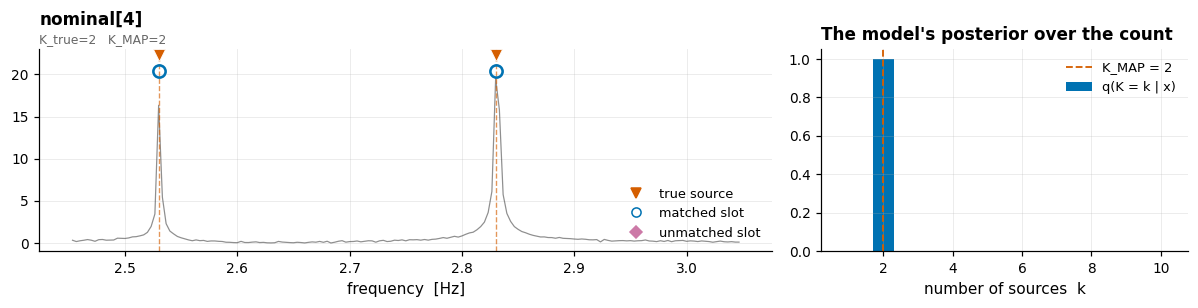

In [2]:
# --- One signal, everything the model said about it -------------------------
# What: pick one in-distribution test signal (i = 4 — try others!) and show
#   LEFT:  what the model READ (the spectrum, from pack["nominal_spec"]) with
#          the true sources (dashed) and the slots it activated (top strip);
#   RIGHT: what the model ANSWERED — its cardinality posterior q(K|x)
#          (pack["nominal_q_k"]), with its argmax K_MAP marked.
# Data: precomputed pack arrays; the helper show_signal is in t2_helpers.py.
# Look for: q(K|x) is a sharp spike at the true K, and the model claims
#   exactly that many slots — the ones drawn in the strip on the left.
i = 4
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 2.9),
                               gridspec_kw={"width_ratios": [2, 1]})
show_signal("nominal", i, ax=ax0, legend=True)
q = pack["nominal_q_k"][i]
kmap = int(pack["nominal_k_pred"][i])
ax1.bar(np.arange(1, M + 1), q, width=0.6, color=C["pred"],
        label="q(K = k | x)")
ax1.axvline(kmap, color=C["truth"], ls="--", lw=1.2, label=f"K_MAP = {kmap}")
ax1.set_xlabel("number of sources  k"); ax1.set_ylim(0, 1.05); ax1.legend()
title2(ax1, "The model's posterior over the count")
plt.tight_layout()

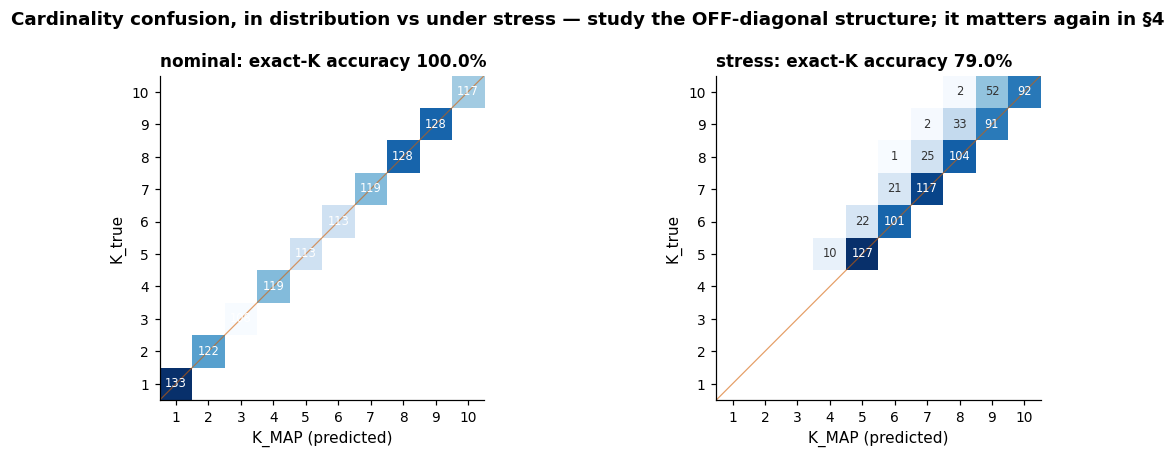

In [3]:
# --- Meet the model: how well does it COUNT, in vs out of distribution? ---
# What: aggregate the SAME two pack arrays over ALL signals — K_true (what
#   the simulator injected) vs K_MAP (the model's offline answer) — into a
#   confusion matrix per subset. No model runs here; this is bookkeeping.
# Look for: where the off-diagonal mass sits relative to the diagonal, and
#   on WHICH side. Keep that in mind — §4 asks about it.
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for ax, subset in zip(axes, SUBSETS):
    kt = pack[f"{subset}_k_true"]; kp = pack[f"{subset}_k_pred"]
    cm = np.zeros((M, M), int)
    for a, b in zip(kt, kp):
        cm[a - 1, b - 1] += 1
    ax.imshow(np.where(cm > 0, cm, np.nan), cmap="Blues", origin="lower")
    for r in range(M):
        for c_ in range(M):
            if cm[r, c_] > 0:
                ax.text(c_, r, cm[r, c_], ha="center", va="center",
                        fontsize=7.5,
                        color="white" if cm[r, c_] > cm.max() * 0.6
                        else C["ink"])
    ax.plot([-0.5, M - 0.5], [-0.5, M - 0.5], color=C["truth"], lw=0.8,
            alpha=0.6)
    ax.set_xticks(range(M), range(1, M + 1))
    ax.set_yticks(range(M), range(1, M + 1))
    ax.set_xlabel("K_MAP (predicted)"); ax.set_ylabel("K_true")
    ax.grid(False)
    acc = (kt == kp).mean()
    title2(ax, f"{subset}: exact-K accuracy {acc:.1%}")
fig.suptitle("Cardinality confusion, in distribution vs under stress — "
             "study the OFF-diagonal structure; it matters again in §4",
             fontweight="semibold")
plt.tight_layout()

In [4]:
# --- Optional: run the network YOURSELF, right now --------------------------
# If you pre-downloaded the 464 MB checkpoint (pre-workshop email /
# appendix A0), this runs the ACTUAL pretrained model on a brand-new signal
# the pack has never seen: forward pass → q(K|x) → slots → flow posteriors.
# Without the checkpoint it just tells you so — the session needs only the
# pack. Change seed and K; first call loads the model (~15 s), re-runs are
# instant.
live_demo(seed=20260714, K=5)

model loaded: 31.3M parameters (cached for re-runs)


fresh signal (seed 20260714):  K_true = 5   K_MAP = 5   max q(K|x) = 1.000
  true f = 2.5775 Hz   slot posterior median = 2.5775 Hz   (|Δf| = 0.03 mHz)
  true f = 2.6579 Hz   slot posterior median = 2.6579 Hz   (|Δf| = 0.01 mHz)
  true f = 2.7423 Hz   slot posterior median = 2.7424 Hz   (|Δf| = 0.12 mHz)
  true f = 2.7616 Hz   slot posterior median = 2.7616 Hz   (|Δf| = 0.01 mHz)
  true f = 2.9058 Hz   slot posterior median = 2.9058 Hz   (|Δf| = 0.03 mHz)


## §2 — Inspect candidate slots

(Convention used everywhere, worth pinning now: parameter rows are
`[amp, phase, freq]` — **frequency is column 2**. Slot frequencies print
in Hz; posterior widths σ_f in **mHz** — the model's typical claimed
precision is a fraction of the 3.33 mHz frequency bin.)

For each example below, answer **before** reading the status column:
1. How many slots does the model claim, and does that match $K_{\rm true}$?
2. Which of the claimed slots are matched to a true source?
3. Is an unmatched claimed slot a **duplicate** (near another slot) or
   sitting on nothing?

── nominal[4]   K_true=2   K_MAP=2
slot    f [Hz]  σ_f [mHz]     A  status
   0    2.8305       0.03  1.02  matched → source 0 (|Δf|=0.00 mHz)
   1    2.5300       0.03  0.66  matched → source 1 (|Δf|=0.00 mHz)
   2    2.6042       4.00  0.32  surplus (not claimed)
   3    2.5298       0.08  0.71  surplus (not claimed)
   4    2.6307       6.21  0.44  surplus (not claimed)
   5    2.5698       1.63  0.49  surplus (not claimed)
   6    2.5463       0.33  0.50  surplus (not claimed)
   7    2.5593       0.91  0.50  surplus (not claimed)
   8    2.5408       0.49  0.51  surplus (not claimed)
   9    2.5507       0.52  0.57  surplus (not claimed)

── stress[1]   K_true=9   K_MAP=9
slot    f [Hz]  σ_f [mHz]     A  status
   0    2.9392       0.06  1.11  matched → source 1 (|Δf|=0.07 mHz)
   1    2.7252       0.45  1.07  matched → source 0 (|Δf|=0.34 mHz)
   2    2.8216       0.10  1.15  matched → source 8 (|Δf|=0.00 mHz)
   3    2.5944       0.10  0.94  matched → source 3 (|Δf|=0.19 mHz)
  

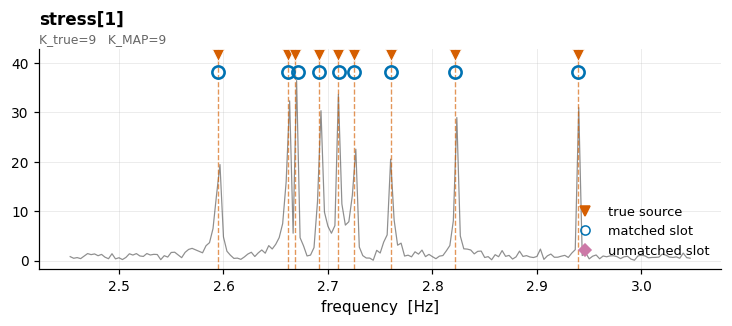

In [5]:
# --- The per-signal view you'll use all afternoon ---------------------------
# What: slot_table(subset, i) prints, for ONE signal, every slot's stored
#   MAP frequency/amplitude, claimed width σ_f, and whether
#   Hungarian matching pairs it with a true source (helpers: t2_helpers.py;
#   all numbers come from the pack). show_signal draws the same signal.
# Do: read nominal[4] first (easy), then stress[1] — answer the three
#   questions above BEFORE looking at each status column.
slot_table("nominal", 4)        # an easy one
slot_table("stress", 1)         # look closely
show_signal("stress", 1, legend=True);

## §3 — Stable slot specialization is *not* the same as physical identity

The SlotFlow paper (Fig. 4) reports emergent slot–frequency
specialization. We test it two ways, with the same fixed K=5 catalogue:

1. **Noise stability** — 20 fresh noise realizations of the *same*
   catalogue. If specialization is real, each slot should hold the same
   source every time. *(Spoiler: on this catalogue it does, in all 20 draws
   — an interesting property, and note the mapping is not frequency-ordered.
   One catalogue and 20 draws is a passed test with a stated scope, not a
   general law.)*
2. **Structural stability** — the catalogue itself changes: one source
   inserted below the band, one removed, all frequencies shifted by
   +10 mHz (an adjacent-window proxy). Does slot $i$ keep tracking "its"
   source?

The distinction this section installs: **within a fixed configuration, slot
specialization was perfectly stable in everything we measured here — and a
slot index is still an internal model convention, not a persistent
astrophysical identifier.**

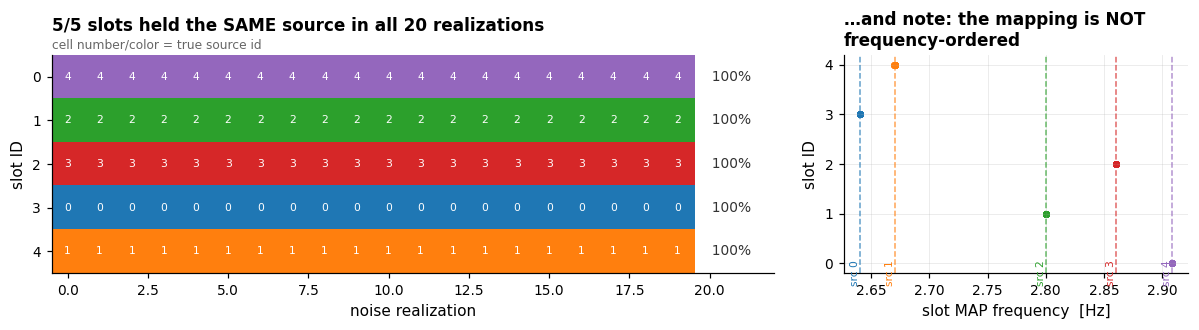

In [6]:
# --- Experiment 1: same catalogue, 20 fresh noise draws --------------------
truth5 = pack["stab_truth"]
n_real = len(pack["stab_q_k"])
grid = np.full((5, n_real), -1)
for r in range(n_real):
    kp = int(pack["stab_k_pred"][r])
    pairs, _, _ = match_catalogue(pack["stab_maps"][r][:kp], truth5)
    for s, j in pairs:
        if s < 5:
            grid[s, r] = j

stab_pct = [(grid[s] == np.bincount(grid[s][grid[s] >= 0]).argmax()).mean()
            for s in range(5)]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.1),
                               gridspec_kw={"width_ratios": [2.1, 1]})
ax0.imshow(grid, cmap="tab10", vmin=0, vmax=9, aspect="auto")
for s in range(5):
    for r in range(n_real):
        ax0.text(r, s, grid[s, r], ha="center", va="center", fontsize=7,
                 color="white")
    ax0.text(n_real - 0.2, s, f"  {stab_pct[s]:.0%}", va="center",
             fontsize=9, color=C["ink"])
ax0.set_xlabel("noise realization"); ax0.set_ylabel("slot ID")
ax0.set_xlim(-0.5, n_real + 2); ax0.grid(False)
title2(ax0, f"{sum(p == 1 for p in stab_pct)}/5 slots held the SAME source "
       f"in all {n_real} realizations", "cell number/color = true source id")

for s in range(5):
    fs = [pack["stab_maps"][r][s, 2] for r in range(n_real)
          if s < int(pack["stab_k_pred"][r])]
    ax1.scatter(fs, [s] * len(fs), s=12, color=plt.cm.tab10(grid[s, 0]))
for j, f in enumerate(truth5[:, 2]):
    ax1.axvline(f, color=plt.cm.tab10(j), ls="--", lw=1.0, alpha=0.7)
    ax1.text(f, -0.45, f"src {j}", rotation=90, fontsize=7, ha="right",
             va="bottom", color=plt.cm.tab10(j))
ax1.set_xlabel("slot MAP frequency  [Hz]"); ax1.set_ylabel("slot ID")
title2(ax1, "…and note: the mapping is NOT\nfrequency-ordered")
plt.tight_layout()

Within each configuration the mapping repeated exactly across all 8 noise draws
we ran — and one structural change (a single inserted source) reshuffles which
slot holds which source. On this evidence specialization behaves like a property
of the (model, configuration) pair rather than an identity you can carry across
catalogues.


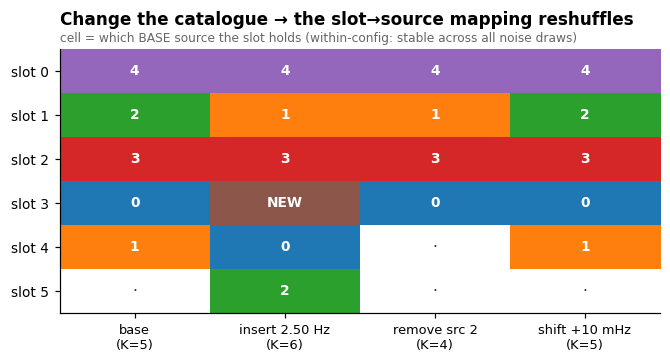

In [7]:
# --- Experiment 2: change the CATALOGUE, not the noise ---------------------
CONFIGS = ["base", "insert", "remove", "shift"]
# truth-row -> base-source id per config (5 = the NEW inserted source)
BASE_ID = {"base": [0, 1, 2, 3, 4], "insert": [0, 1, 2, 3, 4, 5],
           "remove": [0, 1, 3, 4], "shift": [0, 1, 2, 3, 4]}

mat = np.full((6, len(CONFIGS)), -1)
consistent = True
for c_, cfg in enumerate(CONFIGS):
    truth = pack[f"stab2_{cfg}_truth"]
    per_real = []
    for r in range(len(pack[f"stab2_{cfg}_q_k"])):
        kp = int(pack[f"stab2_{cfg}_k_pred"][r])
        pairs, _, _ = match_catalogue(pack[f"stab2_{cfg}_maps"][r][:kp],
                                      truth)
        per_real.append({s: BASE_ID[cfg][j] for s, j in pairs})
    consistent &= all(m == per_real[0] for m in per_real)
    for s, src in per_real[0].items():
        if s < 6:
            mat[s, c_] = src

fig, ax = plt.subplots(figsize=(6.2, 3.4))
shown = np.ma.masked_less(mat, 0)
ax.imshow(shown, cmap="tab10", vmin=0, vmax=9, aspect="auto")
for s in range(6):
    for c_ in range(len(CONFIGS)):
        if mat[s, c_] >= 0:
            lbl = "NEW" if mat[s, c_] == 5 else str(mat[s, c_])
            ax.text(c_, s, lbl, ha="center", va="center", fontsize=9,
                    color="white", fontweight="semibold")
        else:
            ax.text(c_, s, "·", ha="center", va="center", color=C["ink"])
ax.set_xticks(range(len(CONFIGS)),
              ["base\n(K=5)", "insert 2.50 Hz\n(K=6)", "remove src 2\n(K=4)",
               "shift +10 mHz\n(K=5)"], fontsize=8.5)
ax.set_yticks(range(6), [f"slot {s}" for s in range(6)])
ax.grid(False)
title2(ax, "Change the catalogue → the slot→source mapping reshuffles",
       "cell = which BASE source the slot holds "
       f"(within-config: {'stable' if consistent else 'UNSTABLE'} across "
       "all noise draws)")
plt.tight_layout()

print("Within each configuration the mapping repeated exactly across all "
      "8 noise draws\nwe ran — and one structural change (a single inserted "
      "source) reshuffles which\nslot holds which source. On this evidence "
      "specialization behaves like a property\nof the (model, "
      "configuration) pair rather than an identity you can carry across\n"
      "catalogues.")

**Four different things that are easy to conflate** (one sentence each,
then onward):
**slot ID** — an internal index (stable per configuration, reshuffled by
structural change — you just measured both) · **catalogue member** — a
predicted object, *after* matching · **physical identity** — a persistent
astrophysical source · **tracking** — the association problem across
changing catalogues and windows, which streaming inference must solve *on
top of* the model.

## §4 — Failure gallery: multi-label diagnosis

Catalogue failures are **causal chains, not mutually exclusive classes**:
a merge implies an undercount, which usually implies a miss. So this
gallery works like real triage — for each mystery case, **mark every label
that applies**:

| label | meaning |
|---|---|
| miss | a true source has no matched claimed slot |
| merge | two close true sources represented by one prediction |
| duplicate | a claim on a source another claim already explains |
| undercount | $K_{\rm MAP} < K_{\rm true}$ |
| overcount | $K_{\rm MAP} > K_{\rm true}$ |
| exact-K wrong | count correct, membership wrong |

The exemplars were mined by open criteria (`mine_failures.py`) and the
base rates are shown at the reveal. One label does not occur anywhere in
these 2,000 signals — you may already have spotted the evidence in §1's
confusion matrices; the reveal makes it explicit.

Mark ALL applicable labels per case (miss / merge / duplicate / undercount / overcount / exact-K wrong), then run the reveal.


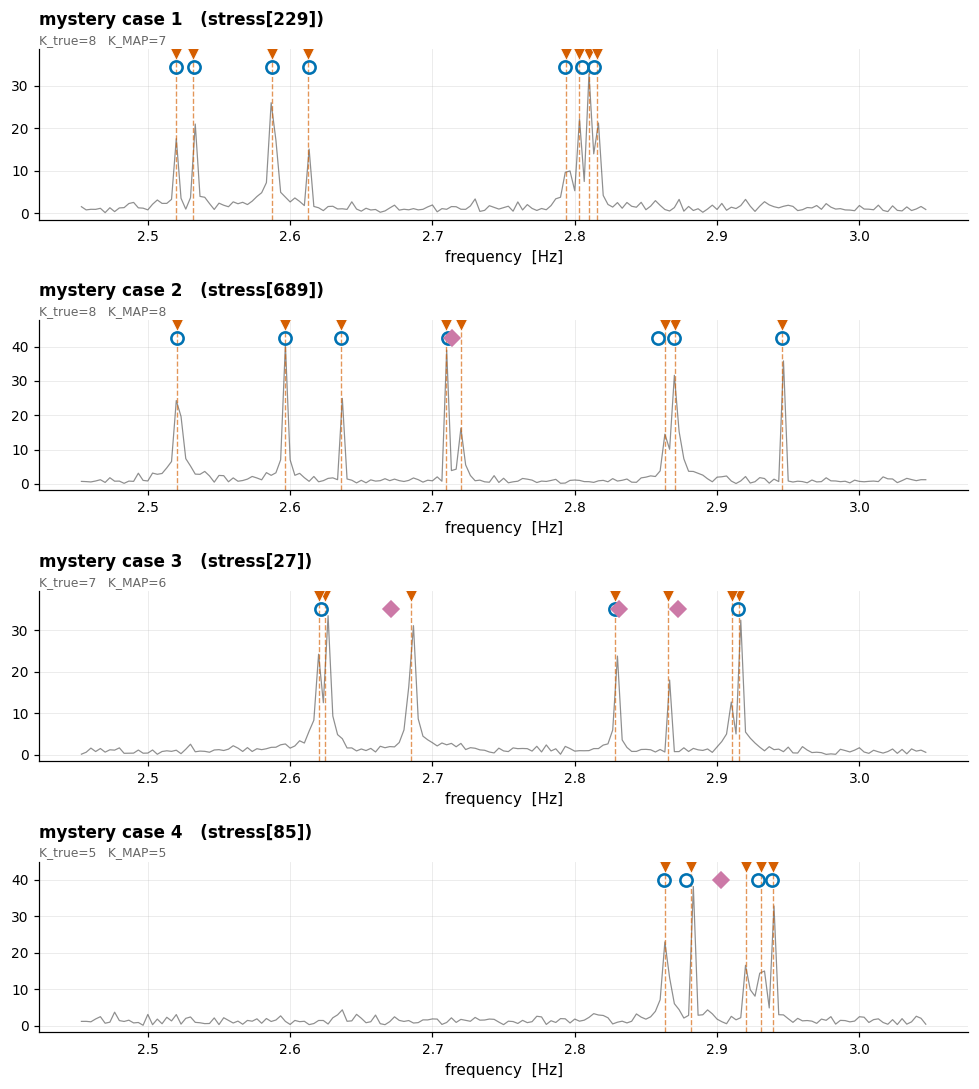

In [8]:
mystery = gallery["mystery"]
fig, axes = plt.subplots(len(mystery), 1, figsize=(9, 2.5 * len(mystery)))
for n, (ax, e) in enumerate(zip(np.atleast_1d(axes), mystery), 1):
    show_signal(e["subset"], e["index"], ax=ax,
                title=f"mystery case {n}   ({e['subset']}[{e['index']}])")
plt.tight_layout()
print("Mark ALL applicable labels per case "
      "(miss / merge / duplicate / undercount / overcount / exact-K wrong), "
      "then run the reveal.")

case 1: miss, undercount                           (stress[229], K_true=8, K_MAP=7)
case 2: duplicate, exactK_wrong, miss              (stress[689], K_true=8, K_MAP=8)
case 3: duplicate, merge, miss, undercount         (stress[27], K_true=7, K_MAP=6)
case 4: exactK_wrong, miss                         (stress[85], K_true=5, K_MAP=5)

the compound case dissected (stress[27]):
── stress[27]   K_true=7   K_MAP=6
slot    f [Hz]  σ_f [mHz]     A  status
   0    2.9146       0.09  1.19  matched → source 1 (|Δf|=0.53 mHz)
   1    2.8281       0.21  0.83  matched → source 4 (|Δf|=0.41 mHz)
   2    2.8728       0.64  0.62  CLAIMED, UNMATCHED
   3    2.6218       0.11  1.49  matched → source 6 (|Δf|=1.47 mHz)
   4    2.6706       1.84  1.13  CLAIMED, UNMATCHED
   5    2.8310       0.21  0.97  CLAIMED, UNMATCHED
   6    2.6860       0.86  1.00  surplus (not claimed)
   7    2.6855       1.94  1.27  surplus (not claimed)
   8    2.6478      19.89  1.04  surplus (not claimed)
   9    2.6722      22.

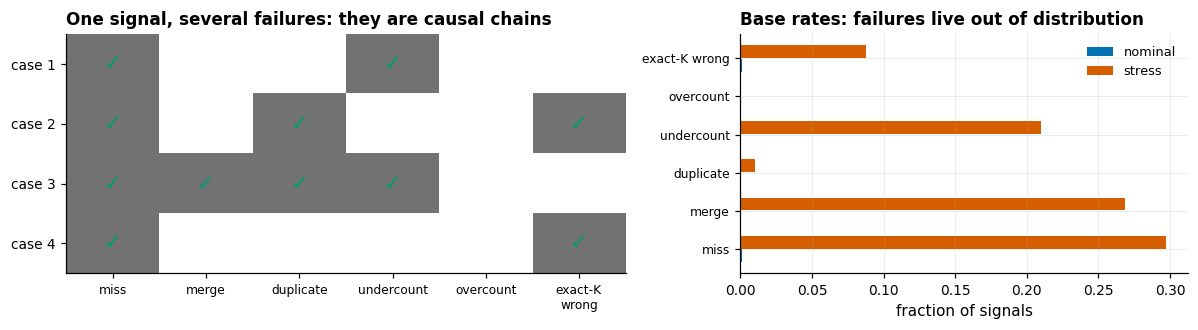

In [9]:
LBL = gallery["labels"]
mat = np.array([[l in e["labels"] for l in LBL] for e in mystery])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.1),
                               gridspec_kw={"width_ratios": [1.25, 1]})
ax0.imshow(mat, cmap="Greys", vmin=0, vmax=1.6, aspect="auto")
for r in range(mat.shape[0]):
    for c_ in range(mat.shape[1]):
        ax0.text(c_, r, "✓" if mat[r, c_] else "", ha="center", va="center",
                 fontsize=14, color=C["rescue"])
ax0.set_xticks(range(len(LBL)),
               [l.replace("exactK_wrong", "exact-K\nwrong") for l in LBL],
               fontsize=8)
ax0.set_yticks(range(len(mystery)),
               [f"case {n+1}" for n in range(len(mystery))])
ax0.grid(False)
title2(ax0, "One signal, several failures: they are causal chains")

y = np.arange(len(LBL))
for dy, subset, colr in [(-0.18, "nominal", C["pred"]),
                         (0.18, "stress", C["truth"])]:
    rates = [gallery["rates"][subset][l]["rate"] for l in LBL]
    ax1.barh(y + dy, rates, height=0.34, color=colr, label=subset)
ax1.set_yticks(y, [l.replace("exactK_wrong", "exact-K wrong") for l in LBL],
               fontsize=8)
ax1.set_xlabel("fraction of signals"); ax1.legend()
title2(ax1, "Base rates: failures live out of distribution")
plt.tight_layout()

for n, e in enumerate(mystery, 1):
    print(f"case {n}: {', '.join(e['labels']):<42} "
          f"({e['subset']}[{e['index']}], K_true={e['k_true']}, "
          f"K_MAP={e['k_pred']})")
compound = max(mystery, key=lambda e: len(e["labels"]))
print(f"\nthe compound case dissected ({compound['subset']}"
      f"[{compound['index']}]):")
slot_table(compound["subset"], compound["index"])
print("The label that never occurs: OVERCOUNT — at the MAP count this "
      "model never\ninvents sources (measured over all 2,000 signals; an "
      "empirical property of THIS\nmodel on THIS data, not a law). All "
      "failure mass is on the undercount side —\nremember that for the "
      "challenge.")

## §5 — The Catalogue Challenge

The network is frozen. Your job is the **decision layer** — the rules
that turn the network's raw outputs (slots + probabilities) into the
final catalogue you would publish:

> *Produce the best catalogue from the candidate slots, the model's count
> posterior — and anything else in the pack.*

**How catalogues are scored here, in plain words** (a claimed source
*detects* a true source when they match within 5 mHz):

| term | meaning |
|---|---|
| recall | fraction of *true* sources that were detected |
| precision | fraction of *claimed* sources that are real |
| false positives / mixture | claimed-but-unreal sources, per signal |
| exact-K accuracy | fraction of signals with the count exactly right |
| F1 | harmonic mean of recall and precision — one number, hides the trade-off |

Rules: develop against `DEV` — short for **development split**, the set you
tune on. Here it is `np.arange(150)`, the first 150 of the 800 stress
signals, small enough that scoring is instant. `FULL` is all 800, and you
run it **once**, at the end. That is the discipline of a blinded analysis:
decide your rule on one set of data, then report on another. (Being precise:
`DEV` is a *subset* of `FULL`, so the final number is not perfectly held
out. With 150 of 800 the effect is small, and in a real analysis you would
keep the two disjoint.) Pick an **operational track**: **Discovery** (maximize recall
subject to ≤ 0.5 false positives per mixture) or **Conservative**
(maximize precision subject to recall ≥ 0.90). The trade-off plot matters
more than any single scalar.

Your toolbox — fair warning: *one of these is a decoy, one is a scalpel
that cuts both ways, and the best move isn't a knob at all*:

1. **Claim a different number of sources.** The model only ever undercounts
   (§4), so the tempting fix is to ask for $K_{\rm MAP}{+}1$ slots. Try it and
   *measure* — the pack stores all ten.
2. **Duplicate suppression** — when two claimed sources are nearly
   identical, keep only the more confident one. (Computer vision calls
   this *non-maximum suppression*, "NMS" — you'll see that name in the
   plots.) Provided below; check *where* it helps and where it hurts.
3. **Everything else in the pack** — per-slot posterior samples and
   widths, and the observed spectrum itself.

In [10]:
print("BASELINE — the model's MAP catalogue, no post-processing")
baseline_dev = evaluate(baseline_catalogue, DEV, "baseline (dev 150)")
baseline_full = evaluate(baseline_catalogue, FULL, "baseline (full 800)")

BASELINE — the model's MAP catalogue, no post-processing
baseline (dev 150)     recall 0.923   precision 0.957   F1 0.940   FP/mix 0.313   exact-K 0.727   median|Δf| 0.14 mHz
baseline (full 800)    recall 0.931   precision 0.959   F1 0.945   FP/mix 0.301   exact-K 0.790   median|Δf| 0.13 mHz


Claiming one EXTRA slot buys about a point of recall and costs ~0.8 more false
positives per mixture: the extra slot only occasionally lands on a real source.
Claiming one FEWER throws away twelve points of recall for almost no precision.
F1 peaks at the model's own count (0.94, vs 0.90 at +1 and 0.88 at −1), and exact-K
accuracy collapses either way.

Re-reading the count cannot help either: q(K|x) is just as confident when it is
wrong. Mean max-q is 0.99 when the count is right and 0.97 when it is wrong, and
90% of the wrong counts are claimed above 0.9. In distribution there are no wrong
counts at all (1200/1200). An empirical property of THIS model on THIS stress set,
not a universal law.


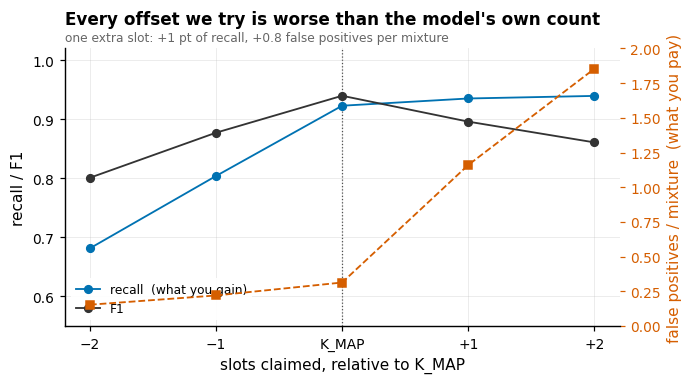

In [11]:
# --- Knob 1: claim a different number of sources -------------------------
# What: the model only ever undercounts (§4), so the tempting fix is to claim
#   MORE slots than K_MAP. The pack stores all 10 forced slots, so we can just
#   try it: K_MAP + d for d = -2 … +2, scored on the dev split.
# Look for: LEFT — what you gain (recall) against what you pay (false
#   positives per mixture, right-hand axis). RIGHT — why re-reading the count
#   cannot help: the confidence the model attaches to a WRONG count.
def count_offset_catalogue(i, d):
    """Claim K_MAP + d slots instead of the model's own K_MAP."""
    k = int(pack["stress_k_pred"][i]) + d
    return pack["stress_maps"][i][:max(0, min(M, k))]


deltas = [-2, -1, 0, 1, 2]
sw = [evaluate(lambda i, d=d: count_offset_catalogue(i, d), DEV, quiet=True)
      for d in deltas]

fig, ax0 = plt.subplots(figsize=(6.4, 3.6))
ax0.plot(deltas, [s["recall"] for s in sw], marker="o", ms=5, color=C["pred"],
         label="recall  (what you gain)")
ax0.plot(deltas, [s["f1"] for s in sw], marker="o", ms=5, color=C["ink"],
         label="F1")
ax0.axvline(0, color=C["ink"], lw=0.8, ls=":", zorder=0)
ax0.set_xticks(deltas, ["−2", "−1", "K_MAP", "+1", "+2"])
ax0.set_xlabel("slots claimed, relative to K_MAP")
ax0.set_ylabel("recall / F1"); ax0.set_ylim(0.55, 1.02)
ax0.legend(loc="lower left", fontsize=8, frameon=True, framealpha=0.92,
           edgecolor="none")
axb = ax0.twinx()                                  # the cost, on its own axis
axb.plot(deltas, [s["fp_per_mixture"] for s in sw], marker="s", ms=5, ls="--",
         color=C["truth"])
axb.set_ylabel("false positives / mixture  (what you pay)", color=C["truth"])
axb.tick_params(axis="y", colors=C["truth"]); axb.set_ylim(0, 2.0)
axb.grid(False)
title2(ax0, "Every offset we try is worse than the model's own count",
       "one extra slot: +1 pt of recall, +0.8 false positives per mixture")

q_max = pack["stress_q_k"].max(axis=-1)
right = pack["stress_k_pred"] == pack["stress_k_true"]
plt.tight_layout()

print("Claiming one EXTRA slot buys about a point of recall and costs ~0.8 "
      "more false\npositives per mixture: the extra slot only occasionally "
      "lands on a real source.\nClaiming one FEWER throws away twelve points "
      "of recall for almost no precision.\nF1 peaks at the model's own count "
      "(0.94, vs 0.90 at +1 and 0.88 at −1), and exact-K\naccuracy collapses "
      "either way.")
print(f"\nRe-reading the count cannot help either: q(K|x) is just as confident "
      f"when it is\nwrong. Mean max-q is {q_max[right].mean():.2f} when the "
      f"count is right and {q_max[~right].mean():.2f} when it is wrong, and\n"
      f"{(q_max[~right] > 0.9).mean():.0%} of the wrong counts are claimed "
      "above 0.9. In distribution there are no wrong\ncounts at all "
      "(1200/1200). An empirical property of THIS model on THIS stress set,\n"
      "not a universal law.")

### Knob 2 — duplicate suppression, step by step

Sometimes the model spends two slots on **one** source: two claims a fraction
of a millihertz apart, where only one real source exists. Duplicate suppression
("non-maximum suppression", NMS, the name computer vision uses) removes the
redundant one. The rule below is five lines, and worth reading carefully
because *how* it decides is the whole story:

1. **Walk the claims in order.** The network instantiates slots in index order,
   so slot 0 first. That order is the priority: earlier claims win.
2. **Measure how close two claims are** — but in *normalized* units, not raw
   ones:
   $$d = \Big(\frac{\Delta f}{5~\text{mHz}}\Big)^{2}
        + \Big(\frac{\Delta A}{0.25}\Big)^{2}.$$
   Raw units would be meaningless here: frequencies are around 2.7 (Hz) and
   amplitudes around 1, so frequency would dominate any comparison by a factor
   of a thousand. Dividing each by a scale we care about — the matching
   tolerance for frequency, a quarter for amplitude — puts them on equal terms.
3. **Reject a claim if it lands within ε of one already accepted.** With
   $\varepsilon = 4$, "too close" means roughly *two* of those combined units:
   e.g. two claims 10 mHz apart at equal amplitude give $d = 4$ and just
   survive, while 5 mHz apart gives $d = 1$ and the second is dropped.

So ε is the one number you tune. Small ε removes only near-identical claims.
Large ε starts deleting genuinely different sources. The next cell measures
exactly where that turns — with one case where suppression helps and one where
it destroys a correct answer.

In [12]:
# --- Knob 2: duplicate suppression, a.k.a. NMS (reference) -----------------
# The rule: walk the rows in priority order (slot 0 first) and reject a row
# closer than eps to any already-accepted row, where "close" is
# slot_distance = (Δf/5 mHz)² + (ΔA/0.25)².
def my_suppress_duplicates(cat, eps=4.0, sigma_f=TOL_F, sigma_a=0.25):
    """Catalogue-level duplicate suppression (non-maximum suppression).

    cat: (n, 3) rows [amp, phase, freq], in priority order — for a model
    catalogue that is the slot order the network instantiated. Greedily
    accept rows, rejecting any whose normalized distance
    slot_distance(row, kept_row) to an already-kept row is below eps.
    Returns the list of kept indices.
    """
    kept = []
    for i in range(len(cat)):
        if all(slot_distance(cat[i], cat[j], sigma_f, sigma_a) >= eps
               for j in kept):
            kept.append(i)
    return kept

# self-checks: a synthetic duplicate is removed; a distant pair is kept
cat = np.array([[1.0, 0.0, 2.700], [0.9, 0.0, 2.701], [1.1, 0.0, 2.900]])
kept = list(my_suppress_duplicates(cat))
assert kept == [0, 2], f"expected [0, 2], got {kept}"
kept2 = list(my_suppress_duplicates(cat[[0, 2]]))
assert kept2 == [0, 1], f"expected [0, 1], got {kept2}"
print("NMS checks passed ✔")
catalogue_metrics.suppress_duplicates = my_suppress_duplicates  # plug in

NMS checks passed ✔


In crowded source inference, geometric closeness is not sufficient evidence of duplication.


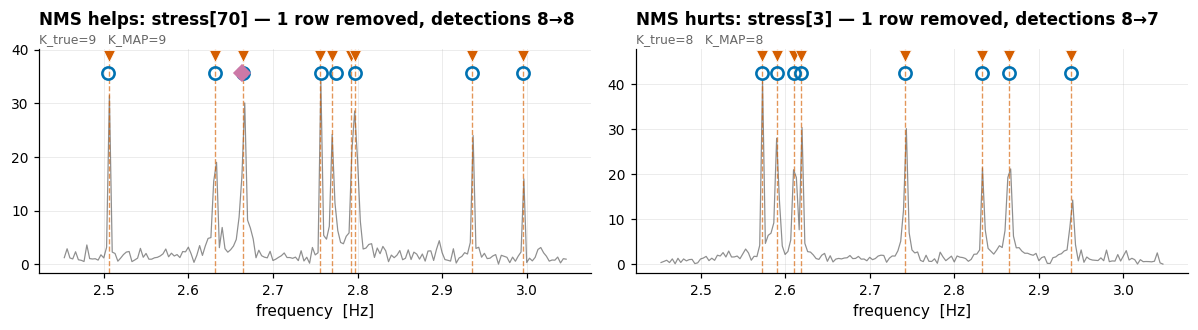

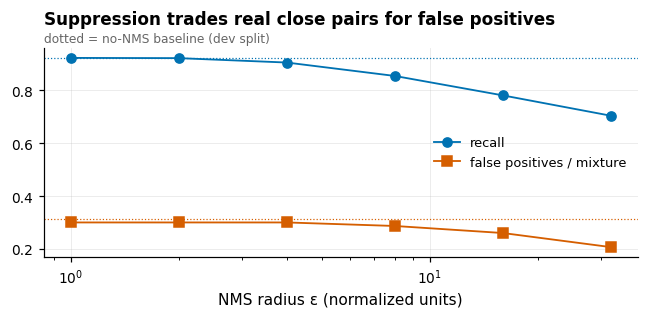

In [13]:
# --- Knob 2, honestly: one case where NMS helps, one where it hurts --------
def nms_catalogue(i, eps=4.0):
    return build_catalogue(pack["stress_maps"][i],
                           int(pack["stress_k_pred"][i]), nms_eps=eps)


helps = gallery["nms_cases"]["helps"]
hurts = gallery["nms_cases"]["hurts"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.1))
for ax, case, verdict in [(axes[0], helps, "helps"),
                          (axes[1], hurts, "hurts")]:
    i = case["index"]
    before = baseline_catalogue(i)
    after = nms_catalogue(i)
    tru = TRUTHS["stress"][i]
    det_b = len(match_catalogue(before, tru)[0])
    det_a = len(match_catalogue(after, tru)[0])
    show_signal("stress", i, ax=ax,
                title=f"NMS {verdict}: stress[{i}] — "
                      f"{len(before) - len(after)} row removed, "
                      f"detections {det_b}→{det_a}")

plt.tight_layout()

eps_grid = [1.0, 2.0, 4.0, 8.0, 16.0, 32.0]
res = [evaluate(lambda i, e=e: nms_catalogue(i, e), DEV, quiet=True)
       for e in eps_grid]
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(eps_grid, [r["recall"] for r in res], marker="o", color=C["pred"],
        label="recall")
ax.plot(eps_grid, [r["fp_per_mixture"] for r in res], marker="s",
        color=C["truth"], label="false positives / mixture")
ax.axhline(baseline_dev["recall"], color=C["pred"], ls=":", lw=0.8)
ax.axhline(baseline_dev["fp_per_mixture"], color=C["truth"], ls=":", lw=0.8)
ax.set_xscale("log"); ax.set_xlabel("NMS radius ε (normalized units)")
ax.legend()
title2(ax, "Suppression trades real close pairs for false positives",
       "dotted = no-NMS baseline (dev split)")
plt.tight_layout()
print("In crowded source inference, geometric closeness is not sufficient "
      "evidence of duplication.")

### The reveal — go back to the data

The observation itself is in the pack. When a merged or missed source is
resolvable, it often still leaves **a separate spectral peak** behind —
often enough to be worth exploiting. So this decision layer keeps the
network's catalogue and **rescues candidates from peaks that no entry
explains** — with an explicit three-step structure any real pipeline
would use:

1. **candidate detection** — `find_peaks` above a height threshold;
2. **rough initialization** — peak height and bin-center frequency;
3. **local refinement** — sub-bin frequency from a parabolic fit to the
   log-spectrum around the peak. *(A real pipeline would refit the
   candidate sinusoid on the raw time series — that needs data outside
   this magnitude-only pack, and is the natural take-home.)*

**What the height threshold does, since it is the knob you tune.** `PEAKS[i]`
stores every peak of signal *i*'s spectrum with its height expressed as a
**fraction of the tallest peak in that window**. So `height_frac = 0.35` means
"only consider peaks at least 35% as tall as the biggest one here". It is
relative on purpose: the absolute scale changes from signal to signal, the
shape does not.

That one number sets how aggressive the rescue is:

| height threshold | behaviour |
|---|---|
| high (0.50) | only obvious peaks are claimed — few additions, few mistakes |
| medium (0.35) | the setting used below |
| low (0.25) | more real sources recovered, and more noise bumps claimed too |

Which is why the strategies in the final plot are labelled by their height
threshold: `rescue 0.50`, `rescue 0.35`, `rescue 0.25` are the *same code* at
three levels of aggressiveness, and they trace out the trade-off between recall
and contamination. There is no universally right value — it depends which
operational track you picked.

In [14]:
# =====================  YOUR TASK — the filled-in version  =================
# This is exactly the cell you were editing, with the marked block completed:
# keep the network's catalogue, then add a candidate for every spectral peak
# that no catalogue row explains. Eight lines, and it is the whole idea.
# (rescue_catalogue below is the same move with a tunable height threshold and
#  the extra local-refinement stage.)
# ===========================================================================
def build_my_catalogue(i):
    cat = baseline_catalogue(i)          # start from the model's own catalogue

    # ----------------------- YOUR CODE HERE ------------------------------
    pk_f, pk_h, _ = PEAKS[i]             # peaks of the spectrum the model READ
    rows = list(cat)
    for f0, h in zip(pk_f, pk_h):
        if h < 0.35:                      # too small to be worth claiming
            continue
        if np.abs(cat[:, 2] - f0).min() <= TOL_F:
            continue                      # a catalogue row already explains it
        rows.append([h, 0.0, f0])         # amp = peak height, phase unused
    cat = np.array(rows)
    # ---------------------------------------------------------------------

    return cat


mine_dev = check_my_catalogue(build_my_catalogue)

contract ok ✔   (n, 3) rows of [amp, phase, freq]

the model itself (dev 150) recall 0.923   precision 0.957   F1 0.940   FP/mix 0.313   exact-K 0.727   median|Δf| 0.14 mHz
yours              (dev 150) recall 0.963   precision 0.957   F1 0.960   FP/mix 0.333   exact-K 0.733   median|Δf| 0.15 mHz

→ you beat the model's own catalogue: F1 0.940 → 0.960  🎉
  Now check the trade-off plot below — F1 hides which way you paid for it.


In [15]:
def refine_freq(spec_band, j):
    """Sub-bin frequency: parabolic interpolation on log|X| around bin j."""
    if 0 < j < len(spec_band) - 1:
        y = np.log(spec_band[j - 1:j + 2].astype(np.float64) + 1e-12)
        denom = y[0] - 2 * y[1] + y[2]
        if denom < 0:
            return FB[j] + np.clip(0.5 * (y[0] - y[2]) / denom, -0.5, 0.5) * DF_BIN
    return FB[j]


def rescue_catalogue(i, height_frac=0.35, refine=True, nms_eps=None):
    """network catalogue -> unexplained-peak proposal -> local refinement."""
    base = baseline_catalogue(i)
    spec_band = pack["stress_spec"][i][BAND].astype(np.float32)
    pk_f, pk_h, pk_j = PEAKS[i]
    rows = list(base)
    for f0, h, j in zip(pk_f, pk_h, pk_j):
        if h < height_frac:
            continue
        if np.abs(base[:, 2] - f0).min() <= TOL_F:
            continue                                   # already explained
        f_ref = refine_freq(spec_band, j) if refine else f0
        rows.append([h, 0.0, f_ref])   # amp = rough init from peak height
    cat = np.array(rows)
    if nms_eps is not None and len(cat) > 1:
        # rows are already in priority order: network catalogue, then rescued
        cat = cat[suppress_duplicates(cat, nms_eps)]
    return cat


# does the refinement step actually help? measure it on rescued candidates
raw_err, ref_err = [], []
for i in FULL:
    tru = TRUTHS["stress"][int(i)]
    base = baseline_catalogue(int(i))
    spec_band = pack["stress_spec"][int(i)][BAND].astype(np.float32)
    for f0, h, j in zip(*PEAKS[int(i)]):
        if h < 0.35 or np.abs(base[:, 2] - f0).min() <= TOL_F:
            continue
        d0 = np.abs(tru[:, 2] - f0).min()
        d1 = np.abs(tru[:, 2] - refine_freq(spec_band, j)).min()
        if min(d0, d1) <= TOL_F:
            raw_err.append(d0); ref_err.append(d1)
print(f"rescued candidates matched to truth: {len(raw_err)}")
print(f"  median |Δf|  bin-center init: {fmt_mhz(np.median(raw_err))}   "
      f"after parabolic refinement: {fmt_mhz(np.median(ref_err))}")
print("  measured result: refinement does NOT beat bin-center here — in "
      "this crowded,\n  noisy regime the peaks are noise- and "
      "leakage-limited, not discretization-\n  limited. The three-step "
      "structure still earns its keep: the refinement stage is\n  where a "
      "real pipeline refits the candidate sinusoid on the raw time series,\n"
      "  which this magnitude-only pack cannot do (the take-home).")

print("\nfinal scorecards (full 800):")
final_baseline = evaluate(baseline_catalogue, FULL, "baseline")
final_rescue = evaluate(lambda i: rescue_catalogue(i, 0.35), FULL,
                        "rescue hf=0.35")

rescued candidates matched to truth: 264
  median |Δf|  bin-center init: 1.00 mHz   after parabolic refinement: 1.00 mHz
  measured result: refinement does NOT beat bin-center here — in this crowded,
  noisy regime the peaks are noise- and leakage-limited, not discretization-
  limited. The three-step structure still earns its keep: the refinement stage is
  where a real pipeline refits the candidate sinusoid on the raw time series,
  which this magnitude-only pack cannot do (the take-home).

final scorecards (full 800):
baseline               recall 0.931   precision 0.959   F1 0.945   FP/mix 0.301   exact-K 0.790   median|Δf| 0.13 mHz


rescue hf=0.35         recall 0.972   precision 0.957   F1 0.965   FP/mix 0.325   exact-K 0.769   median|Δf| 0.14 mHz


The failure mode appears at permissive thresholds (and as double-counting of
already-detected sources) — which is exactly why the trade-off plot below, not a
single F1 number, should pick your operating point.


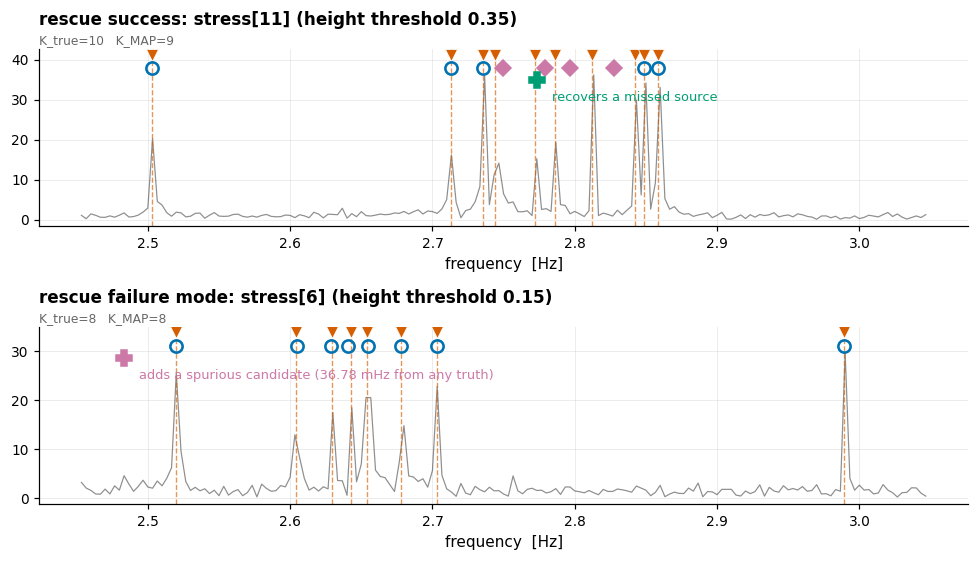

In [16]:
# --- One success and one failure, so nobody over-trusts the trick ----------
suc = gallery["rescue_cases"]["success"]
fpc = gallery["rescue_cases"]["false_positive"]

fig, axes = plt.subplots(2, 1, figsize=(9, 5.2))
for ax, case, hf, verdict in [
        (axes[0], suc, suc["height_frac"], "success"),
        (axes[1], fpc, fpc["height_frac"], "failure mode")]:
    i = case["index"]
    show_signal("stress", i, ax=ax,
                title=f"rescue {verdict}: stress[{i}] "
                      f"(height threshold {hf})")
    ax.plot(case["f_added"], ax.get_ylim()[1] * 0.82, "P",
            color=C["rescue"] if verdict == "success" else C["alert"],
            ms=11, zorder=7)
    kt = int(pack["stress_k_true"][i])
    tru = TRUTHS["stress"][i]
    d = np.abs(tru[:, 2] - case["f_added"]).min()
    ax.annotate(("recovers a missed source" if verdict == "success"
                 else f"adds a spurious candidate ({fmt_mhz(d)} from any "
                      "truth)"),
                (case["f_added"], ax.get_ylim()[1] * 0.82),
                xytext=(10, -14), textcoords="offset points", fontsize=8.5,
                color=C["rescue"] if verdict == "success" else C["alert"])
plt.tight_layout()
print("The failure mode appears at permissive thresholds (and as "
      "double-counting of\nalready-detected sources) — which is exactly "
      "why the trade-off plot below, not a\nsingle F1 number, should pick "
      "your operating point.")


baseline F1 0.940  →  yours 0.960   🎉


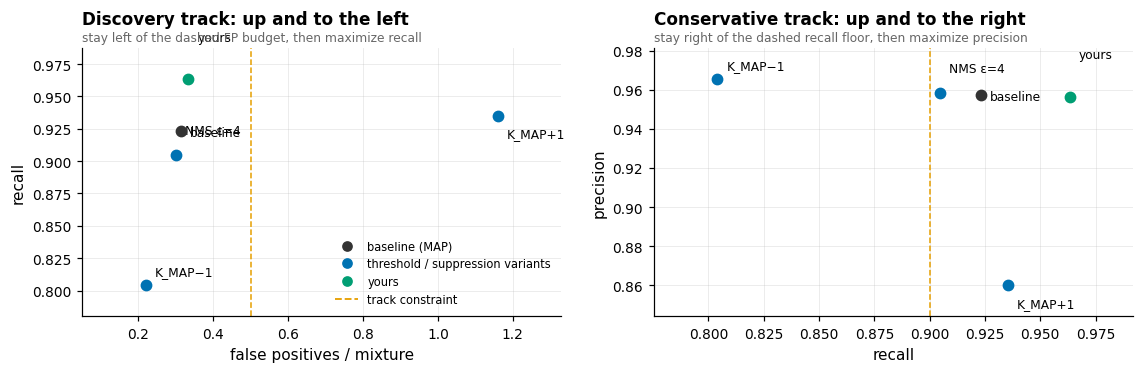

In [17]:
# --- The scoreboard: re-run this after every edit --------------------------
# What: your catalogue against the model's own and the two knobs, on the dev
#   split, in the two views that matter — recall vs contamination (left) and
#   precision vs recall (right). Your point is green.
strategies = {
    "baseline": baseline_catalogue,
    "K_MAP−1": lambda i: count_offset_catalogue(i, -1),
    "K_MAP+1": lambda i: count_offset_catalogue(i, +1),
    "NMS ε=4": lambda i: nms_catalogue(i, 4.0),
    "yours": build_my_catalogue,
}
scores = {n: evaluate(fn, DEV, quiet=True) for n, fn in strategies.items()}

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 3.5))
offsets = [(6, -3), (6, 7), (6, -14), (6, 14), (6, 25)]
for k, (n, sc) in enumerate(scores.items()):
    colr = C["rescue"] if n == "yours" else (
        C["ink"] if n == "baseline" else C["pred"])
    dx, dy = offsets[k % len(offsets)]
    ax0.scatter(sc["fp_per_mixture"], sc["recall"], s=45, color=colr,
                zorder=5)
    ax0.annotate(n, (sc["fp_per_mixture"], sc["recall"]),
                 xytext=(dx, dy), textcoords="offset points", fontsize=8,
                 ha="left")
    ax1.scatter(sc["recall"], sc["precision"], s=45, color=colr, zorder=5)
    ax1.annotate(n, (sc["recall"], sc["precision"]),
                 xytext=(dx, dy), textcoords="offset points", fontsize=8,
                 ha="left")

from matplotlib.lines import Line2D
legend_items = [
    Line2D([], [], marker="o", ls="", color=C["ink"], label="baseline (MAP)"),
    Line2D([], [], marker="o", ls="", color=C["pred"],
           label="threshold / suppression variants"),
    Line2D([], [], marker="o", ls="", color=C["rescue"], label="yours"),
    Line2D([], [], ls="--", color=C["gold"], label="track constraint"),
]
for ax in (ax0, ax1):
    ax.margins(x=0.18, y=0.15)
ax0.axvline(0.5, color=C["gold"], ls="--", lw=1)
ax0.set_xlabel("false positives / mixture"); ax0.set_ylabel("recall")
ax0.legend(handles=legend_items, loc="lower right", fontsize=7.5)
title2(ax0, "Discovery track: up and to the left",
       "stay left of the dashed FP budget, then maximize recall")
ax1.axvline(0.90, color=C["gold"], ls="--", lw=1)
ax1.set_xlabel("recall"); ax1.set_ylabel("precision")
title2(ax1, "Conservative track: up and to the right",
       "stay right of the dashed recall floor, then maximize precision")
plt.tight_layout()

print(f"\nbaseline F1 {baseline_dev['f1']:.3f}  →  yours "
      f"{mine_dev['f1']:.3f}"
      + ("   🎉" if mine_dev["f1"] > baseline_dev["f1"]
         else "   the knobs above won't do it — see the hints…"))

# when you are happy on DEV, run ONCE on the full 800:
# evaluate(build_my_catalogue, FULL, "yours (full 800)")

evaluated 8 strategies x 800 signals in 0.2 s
discovery track (recall @ FP ≤ 0.5/mix):  rescue 0.25  (recall 0.974)
conservative track (precision @ recall ≥ 0.90):  NMS ε=4  (precision 0.959)
No single scalar picks the winner — the OPERATIONAL OBJECTIVE does. Note the
rescue variants also add false positives and slightly lower exact-K accuracy:
the trade-off is real, not a free lunch.


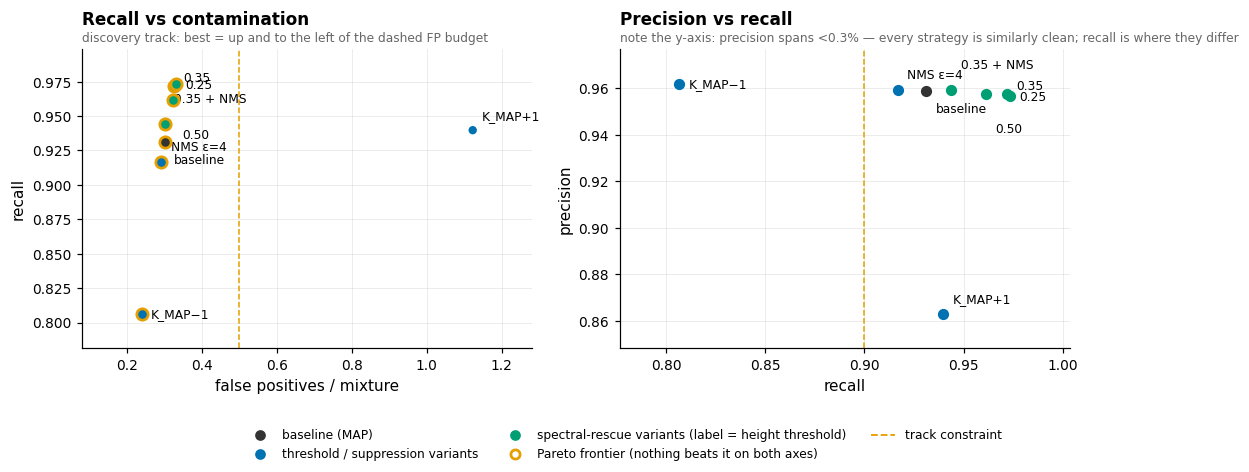

In [18]:
# --- The final trade-off map: every strategy on one canvas -----------------
strategies = {
    "baseline": baseline_catalogue,
    "K_MAP−1": lambda i: count_offset_catalogue(i, -1),
    "K_MAP+1": lambda i: count_offset_catalogue(i, +1),
    "NMS ε=4": lambda i: nms_catalogue(i, 4.0),
    "rescue 0.50": lambda i: rescue_catalogue(i, 0.50),
    "rescue 0.35": lambda i: rescue_catalogue(i, 0.35),
    "rescue 0.25": lambda i: rescue_catalogue(i, 0.25),
    "rescue 0.35 + NMS": lambda i: rescue_catalogue(i, 0.35, nms_eps=4.0),
}
t0 = time.time()
scores = {n: evaluate(fn, FULL, quiet=True) for n, fn in strategies.items()}
print(f"evaluated {len(strategies)} strategies x 800 signals in "
      f"{time.time() - t0:.1f} s")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.3))
pts = [(sc["fp_per_mixture"], sc["recall"], n) for n, sc in scores.items()]
front = sorted(pts)
best = -1
offsets = [(6, -3), (6, 7), (6, -14), (6, 14), (6, -25), (6, 3)]
for k, (x, yv, n) in enumerate(front):
    is_front = yv > best
    best = max(best, yv)
    colr = C["rescue"] if "rescue" in n else (
        C["ink"] if n == "baseline" else C["pred"])
    dx, dy = offsets[k % len(offsets)]
    lbl = n.replace("rescue ", "") if n.startswith("rescue") else n
    ax0.scatter(x, yv, s=55 if is_front else 30, color=colr,
                edgecolor=C["gold"] if is_front else "none", lw=1.8,
                zorder=5)
    ax0.annotate(lbl, (x, yv), xytext=(dx, dy), textcoords="offset points",
                 fontsize=8, ha="left")
    ax1.scatter(scores[n]["recall"], scores[n]["precision"], s=40,
                color=colr, zorder=5)
    ax1.annotate(lbl, (scores[n]["recall"], scores[n]["precision"]),
                 xytext=(dx, dy), textcoords="offset points", fontsize=8,
                 ha="left")

from matplotlib.lines import Line2D
legend_items = [
    Line2D([], [], marker="o", ls="", color=C["ink"], label="baseline (MAP)"),
    Line2D([], [], marker="o", ls="", color=C["pred"],
           label="threshold / suppression variants"),
    Line2D([], [], marker="o", ls="", color=C["rescue"],
           label="spectral-rescue variants (label = height threshold)"),
    Line2D([], [], marker="o", ls="", color="white", mec=C["gold"], mew=1.8,
           label="Pareto frontier (nothing beats it on both axes)"),
    Line2D([], [], ls="--", color=C["gold"], label="track constraint"),
]
for ax in (ax0, ax1):
    ax.margins(x=0.18, y=0.15)          # room so edge labels don't clip
ax0.axvline(0.5, color=C["gold"], ls="--", lw=1)
ax0.set_xlabel("false positives / mixture"); ax0.set_ylabel("recall")
title2(ax0, "Recall vs contamination",
       "discovery track: best = up and to the left of the dashed FP budget")
ax1.axvline(0.90, color=C["gold"], ls="--", lw=1)
ax1.set_xlabel("recall"); ax1.set_ylabel("precision")
title2(ax1, "Precision vs recall",
       "note the y-axis: precision spans <0.3% — every strategy is similarly "
       "clean; recall is where they differ")
# one shared legend BELOW the panels, where it can never fight the data
fig.legend(handles=legend_items, loc="lower center", ncol=3, fontsize=8,
           frameon=False)
plt.tight_layout(rect=(0, 0.12, 1, 1))

disc = max((n for n, s in scores.items() if s["fp_per_mixture"] <= 0.5),
           key=lambda n: scores[n]["recall"])
cons = max((n for n, s in scores.items() if s["recall"] >= 0.90),
           key=lambda n: scores[n]["precision"])
print(f"discovery track (recall @ FP ≤ 0.5/mix):  {disc}  "
      f"(recall {scores[disc]['recall']:.3f})")
print(f"conservative track (precision @ recall ≥ 0.90):  {cons}  "
      f"(precision {scores[cons]['precision']:.3f})")
print("No single scalar picks the winner — the OPERATIONAL OBJECTIVE does. "
      "Note the\nrescue variants also add false positives and slightly "
      "lower exact-K accuracy:\nthe trade-off is real, not a free lunch.")

## §6 — Trust the model? Detection vs calibration  *(instructor-run, ~3′ — just watch)*

Three different questions, three different diagnostics — mixing them is
how pipelines get fooled:

* **A. Detection** — did each true source get an associated prediction?
  (§5 already measured this.)
* **B. Conditional calibration** — *among successfully associated
  sources* (|Δf| ≤ 5 mHz), do the claimed posterior intervals cover the
  truth at their nominal rate?
* **C. Confident errors** — claimed slots far from every true source
  (> 5 mHz) while claiming a tight posterior (σ_f < 1 mHz). Nothing
  downstream can catch these from the model's own outputs alone; it takes
  independent information, such as refitting against the data.

> Accuracy tells you whether the model was right. **Calibration tells you
> whether it knew when it might be wrong.**

calibration arrays built in 0.1 s

A. detection (finite 5 mHz association):
  nominal  matched 6598/6599 true sources (recall 1.000);  1 claimed slots unmatched
  stress   matched 5609/6023 true sources (recall 0.931);  241 claimed slots unmatched

B is CONDITIONAL on association: it asks 'when the model found the source,
were its error bars honest?' — a separate question from whether it found it.
On nominal data the intervals are close to calibrated (a nontrivial pass);
under stress the same model keeps claiming sub-mHz precision while wrong —
the per-slot version of §5's overconfident q(K|x).


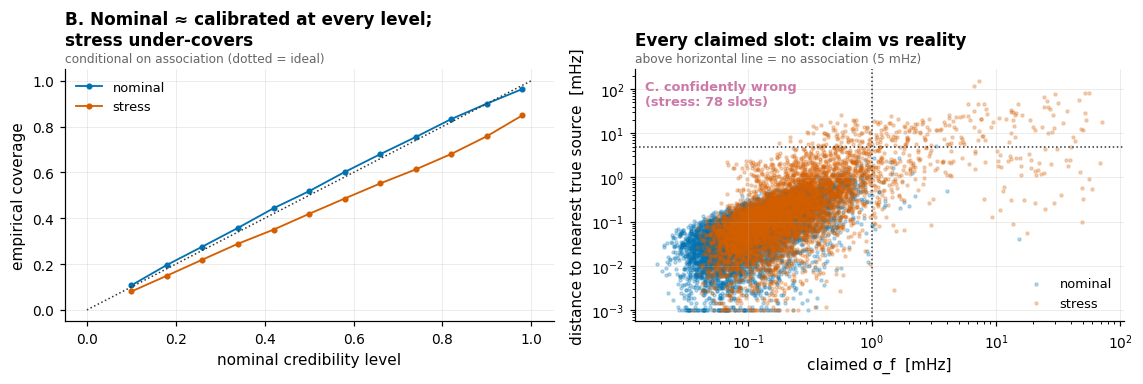

In [19]:
t0 = time.time()
LEVELS = np.linspace(0.10, 0.98, 12)


def calibration(subset):
    """Association at FINITE tolerance, then vectorized coverage."""
    S, tr, d_near, sig_all = [], [], [], []
    n_true = n_match = n_active = 0
    for i in range(len(pack[f"{subset}_k_true"])):
        kmap = int(pack[f"{subset}_k_pred"][i])
        truth = TRUTHS[subset][i]
        maps = pack[f"{subset}_maps"][i]
        pairs, un_p, un_t = match_catalogue(maps[:kmap], truth)  # tol = 5 mHz
        n_true += len(truth); n_match += len(pairs); n_active += kmap
        for s, j in pairs:
            S.append(pack[f"{subset}_samples"][i][s, :, 2])
            tr.append(truth[j, 2])
        for s in range(kmap):                       # ALL claimed slots:
            d_near.append(np.abs(truth[:, 2] - maps[s, 2]).min())
            sig_all.append(pack[f"{subset}_stds"][i][s, 2])
    S = np.asarray(S, np.float64); tr = np.asarray(tr)
    lo = np.quantile(S, (1 - LEVELS) / 2, axis=1)        # (levels, n_match)
    hi = np.quantile(S, 1 - (1 - LEVELS) / 2, axis=1)
    cov = ((tr[None, :] >= lo) & (tr[None, :] <= hi)).mean(axis=1)
    return dict(cov=cov, n_true=n_true, n_match=n_match, n_active=n_active,
                d_near=np.array(d_near), sig=np.array(sig_all))


CAL = {s: calibration(s) for s in SUBSETS}
print(f"calibration arrays built in {time.time() - t0:.1f} s\n")
print("A. detection (finite 5 mHz association):")
for s in SUBSETS:
    c = CAL[s]
    print(f"  {s:<8} matched {c['n_match']}/{c['n_true']} true sources "
          f"(recall {c['n_match']/c['n_true']:.3f});  "
          f"{c['n_active'] - c['n_match']} claimed slots unmatched")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.6))
for s, colr in [("nominal", C["pred"]), ("stress", C["truth"])]:
    ax1.plot(LEVELS, CAL[s]["cov"], marker=".", color=colr, label=s)
ax1.plot([0, 1], [0, 1], color=C["ink"], ls=":", lw=1)
ax1.set_xlabel("nominal credibility level"); ax1.set_ylabel("empirical coverage")
ax1.legend()
title2(ax1, "B. Nominal ≈ calibrated at every level;\nstress under-covers",
       "conditional on association (dotted = ideal)")

for s, colr in [("nominal", C["pred"]), ("stress", C["truth"])]:
    c = CAL[s]
    ax2.scatter(np.maximum(1e3 * c["sig"], 1e-2),
                np.maximum(1e3 * c["d_near"], 1e-3), s=4, alpha=0.25,
                color=colr, label=s)
ax2.axhline(1e3 * TOL_F, color=C["ink"], ls=":", lw=1)
ax2.axvline(1.0, color=C["ink"], ls=":", lw=1)
cw = int(((CAL["stress"]["d_near"] > TOL_F) &
          (CAL["stress"]["sig"] < 1e-3)).sum())
ax2.text(0.02, 0.86, f"C. confidently wrong\n(stress: {cw} slots)",
         transform=ax2.transAxes, fontsize=8.5, color=C["alert"],
         fontweight="semibold")
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_xlabel("claimed σ_f  [mHz]")
ax2.set_ylabel("distance to nearest true source  [mHz]")
ax2.legend(loc="lower right")
title2(ax2, "Every claimed slot: claim vs reality",
       "above horizontal line = no association (5 mHz)")
plt.tight_layout()

print("\nB is CONDITIONAL on association: it asks 'when the model found "
      "the source,\nwere its error bars honest?' — a separate question "
      "from whether it found it.\nOn nominal data the intervals are close "
      "to calibrated (a nontrivial pass);\nunder stress the same model "
      "keeps claiming sub-mHz precision while wrong —\nthe per-slot "
      "version of §5's overconfident q(K|x).")

## §8 — The pipeline decision

Three candidate operational policies for using this model in a LISA-style
analysis, scored against situations you *measured* today:

| situation (measured today) | A · trust | B · gate | C · propose |
|---|---|---|---|
| in-distribution signal (nominal) | ✓ | ✓ | ✓ (wasteful) |
| crowded merge (gallery compound case) | ✗ silent loss | ✗ q is still confident | ✓ rescue found it |
| true duplicate (§4) | ✗ double count | ✗ passes the gate | ✓ NMS / refit |
| confidently-wrong slot (§6 C) | ✗ enters catalogue | ✗ that is the point | ✓ refit rejects |
| genuinely ambiguous close pair (§5 NMS) | △ one entry | △ one entry | △ flagged, still ambiguous |

**A — trust:** accept the MAP catalogue automatically. **B — gate:**
accept only above confidence thresholds — but you measured those
confidences: *gating on a miscalibrated confidence is Policy A wearing a
costume.* **C — propose:** the model generates candidates; a
physics-based validation/refinement step always runs behind it.

### The final question — same as this morning's

Pick any failure you saw today and place it:

$$\text{representation} \;\neq\; \text{inference} \;\neq\;
\text{matching} \;\neq\; \text{decision} \;\neq\;
\text{evaluation}$$

— a merge in an unresolvable pair is *intrinsic ambiguity*; a confidently
wrong σ is a *representation/uncertainty failure*; NMS deleting a real
pair is a *decision failure*; scoring in raw units is an *evaluation
failure*. The skill this workshop practiced is refusing to let one layer
take the blame for another.

> **Some errors can be corrected at the catalogue-decision level. Others
> require better representations, objectives, uncertainty models — or
> going back to the data with physics in hand.**

Where to go from here: the reference solution notebook; the take-home
appendix below; the extension in Tutorial 1 §6; the SlotFlow paper
(arXiv:2511.23228) and this repository, whose `src/` implements everything
you used today with a conditional normalizing flow; and the open problems
this session walked past deliberately — frequency drift $\dot f$, the
LISA response and TDI noise, inter-source correlations, and tracking
across observation windows.

---
## Appendix — take-home material (nothing below is needed live)

* **A0 · Run the pretrained model yourself:** load the released
  checkpoint, generate a fresh signal, and do live what the pack did
  offline — forward pass → q(K|x) → slots → posterior samples.
* **A1 · The cost metric defines "similar":** a constructed example where
  frequency-only and frequency+amplitude matching produce opposite
  catalogues.
* **A2 · Embeddings:** PCA (reproducible) and optional t-SNE of the global
  embedding — and why clusters there are *not* evidence of slot
  specialization.
* **A3 · Where detection dies:** source-level recall vs separation — the
  confusion wall in one curve.
* **A4 · Optional NMS exercise:** re-implement `my_suppress_duplicates`
  (~5 greedy lines) and swap it into the §5 self-check.

In [20]:
# --- A0: run the pretrained model yourself (needs the 464 MB checkpoint) ---
# Everything above read precomputed arrays. This cell does LIVE what the
# pack generator (make_predictions_pack.py) did offline. Requirements:
#   pip install torch nflows          (on Colab: %pip install -q nflows)
#   the released weights + config in ../pretrained_model/test_clariden/:
#     curl -L --create-dirs -o ../pretrained_model/test_clariden/checkpoints/best_model.ckpt \
#          https://github.com/nhouba/slotflow-inference/releases/download/v1.0.0/best_model.ckpt
# Loading the checkpoint takes ~10-20 s; the forward pass itself is ~0.5 s.
import math
# repo layout keeps the model one level up; the standalone folder keeps it here
CKPT_DIR = next((d for d in ["../pretrained_model/test_clariden",
                             "pretrained_model/test_clariden"]
                 if os.path.exists(f"{d}/model_config.pt")),
                "pretrained_model/test_clariden")
needed = [f"{CKPT_DIR}/model_config.pt", f"{CKPT_DIR}/checkpoints"]
missing = [p for p in needed if not os.path.exists(p)]
if missing:
    print("not found:", *missing)
    print("→ follow the download instructions in this cell, then re-run")
else:
    import torch
    sys.path.insert(0, "..")
    from src.model import SlotFlow
    from src.dataset import MultiSinusoidDataset

    cfg = torch.load(f"{CKPT_DIR}/model_config.pt", map_location="cpu",
                     weights_only=False)
    ckpt_file = sorted(f for f in os.listdir(f"{CKPT_DIR}/checkpoints")
                       if f.endswith(".ckpt"))[-1]
    ckpt = torch.load(f"{CKPT_DIR}/checkpoints/{ckpt_file}",
                      map_location="cpu", weights_only=False)
    state = {k.replace("model.", "").replace("_orig_mod.", ""): v
             for k, v in ckpt["state_dict"].items()}
    model = SlotFlow(hidden_dim=cfg["hidden_dim"],
                     max_slots=cfg["max_slots"],
                     use_noise_encoder=cfg.get("use_noise_encoder", False))
    model.load_state_dict(state, strict=True)
    model.eval()
    print(f"model loaded ({sum(p.numel() for p in model.parameters())/1e6:.1f}M "
          f"parameters, checkpoint epoch {ckpt.get('epoch')})")

    # a FRESH signal the pack has never seen (change the seed and K!)
    ds = MultiSinusoidDataset(
        set_size=1, num_samples_long=cfg["num_samples_long"],
        tEnd_long=cfg["tEnd_long"], num_samples_short=cfg["num_samples_short"],
        tEnd_short=cfg["tEnd_short"], max_components=cfg["max_components"],
        freq_range=cfg["freq_range"], amp_range=cfg["amp_range"],
        min_freq_sep=0.01, noise_std=cfg["noise_std"], seed=20260714,
        mode="inference", allowed_K_values=[5])
    x_long, x_short, k_true, comps, params, *_ = ds[0]

    with torch.no_grad():
        out = model(x_long[None], x_short[None])          # the forward pass
        q_live = torch.softmax(out["K_logits"], -1)[0]
        samp = model.flow.sample(200, context=out["context"])  # (K, 200, 4)
    k_map = int(out["K_pred"][0])
    freqs_live = (samp[..., 3] / 3.0 + 2.75).median(dim=1).values  # invert scaling
    print(f"\nK_true = {k_true}   K_MAP = {k_map}   "
          f"max q(K|x) = {q_live.max():.3f}")
    tru_f = sorted(float(f) for _, _, f in params[:k_true])
    est_f = sorted(float(f) for f in freqs_live)
    for tf, ef in zip(tru_f, est_f):
        print(f"  true f = {tf:.4f} Hz   slot posterior median = {ef:.4f} Hz"
              f"   (|Δf| = {fmt_mhz(abs(tf - ef))})")
    print("\nThat is the entire pipeline the pack froze: encoder → q(K|x) → "
          "slots → shared\nflow posteriors. make_predictions_pack.py just "
          "loops this over 2,000 signals.")

model loaded (31.3M parameters, checkpoint epoch 184)



K_true = 5   K_MAP = 5   max q(K|x) = 1.000
  true f = 2.5775 Hz   slot posterior median = 2.5775 Hz   (|Δf| = 0.03 mHz)
  true f = 2.6579 Hz   slot posterior median = 2.6579 Hz   (|Δf| = 0.01 mHz)
  true f = 2.7423 Hz   slot posterior median = 2.7424 Hz   (|Δf| = 0.12 mHz)
  true f = 2.7616 Hz   slot posterior median = 2.7616 Hz   (|Δf| = 0.01 mHz)
  true f = 2.9058 Hz   slot posterior median = 2.9058 Hz   (|Δf| = 0.03 mHz)

That is the entire pipeline the pack froze: encoder → q(K|x) → slots → shared
flow posteriors. make_predictions_pack.py just loops this over 2,000 signals.


In [21]:
# --- A1: the cost function DEFINES what "similar" means --------------------
truth = np.array([[1.40, 0.0, 2.7000],     # bright source
                  [0.60, 0.0, 2.7030]])    # faint source, 3 mHz away
pred  = np.array([[0.62, 0.0, 2.7005],     # faint amp, near bright's f
                  [1.38, 0.0, 2.7025]])    # bright amp, near faint's f

from scipy.optimize import linear_sum_assignment

def assign(cost):
    r, c = linear_sum_assignment(cost)
    return list(zip(r.tolist(), c.tolist()))

c_freq = np.abs(pred[:, 2][:, None] - truth[:, 2][None, :])
c_both = (c_freq / TOL_F) ** 2 + \
         ((pred[:, 0][:, None] - truth[:, 0][None, :]) / 0.25) ** 2
print("frequency-only matching:  ", assign(c_freq))
print("frequency + amplitude:    ", assign(c_both))
print(
    "\nSame predictions, opposite catalogues (the pairs sit 0.5 and "
    "2.5 mHz apart in\nfrequency but swap amplitudes). Hungarian matching "
    "does not define correctness —\nthe COST FUNCTION defines what "
    "'similar' means. Which assignment is\nscientifically meaningful here, "
    "and what does that imply for how catalogues\nshould be SCORED?")
# An uncertainty-aware cost divides each term by the slot's own posterior
# variance — confident slots are held to tighter standards. The pack has
# the per-slot widths.

frequency-only matching:   [(0, 0), (1, 1)]
frequency + amplitude:     [(0, 1), (1, 0)]

Same predictions, opposite catalogues (the pairs sit 0.5 and 2.5 mHz apart in
frequency but swap amplitudes). Hungarian matching does not define correctness —
the COST FUNCTION defines what 'similar' means. Which assignment is
scientifically meaningful here, and what does that imply for how catalogues
should be SCORED?


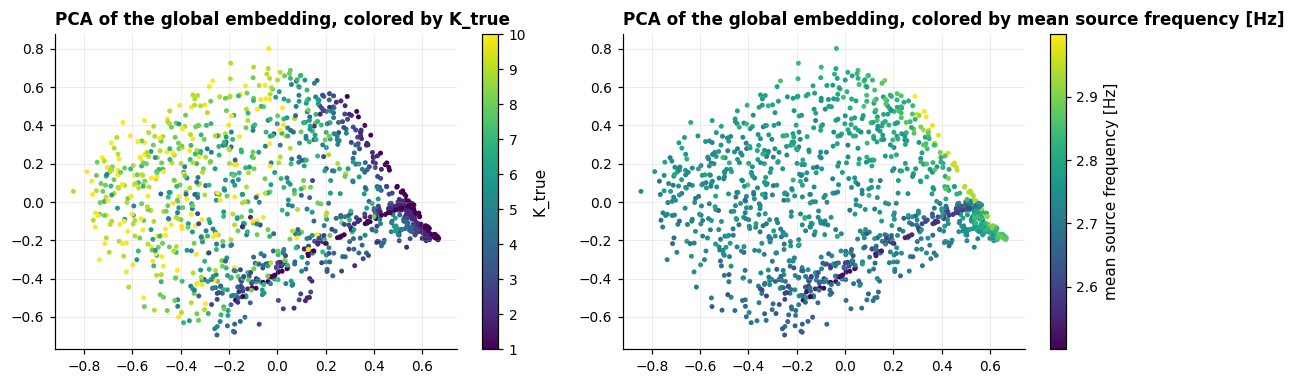

In [22]:
# --- A2: embeddings (and how to over-read them) ----------------------------
# These are PER-SIGNAL embeddings — slot identity enters the flow only via
# the one-hot; t-SNE preserves neighborhoods, not geometry; clusters may
# track physics (K, frequency content) rather than anything about slots.
from sklearn.decomposition import PCA

E = pack["nominal_embed"].astype(np.float32)
kt = pack["nominal_k_true"]
Z = PCA(n_components=2, random_state=0).fit_transform(E)
mean_f = np.array([TRUTHS["nominal"][i][:, 2].mean() for i in range(len(kt))])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for ax, cvals, label in [(axes[0], kt, "K_true"),
                         (axes[1], mean_f, "mean source frequency [Hz]")]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=cvals, s=5, cmap="viridis")
    plt.colorbar(sc, ax=ax, label=label)
    title2(ax, f"PCA of the global embedding, colored by {label}")
plt.tight_layout()

RUN_TSNE = False    # slower, seed-dependent — try it, then change the seed
if RUN_TSNE:
    from sklearn.manifold import TSNE
    Zt = TSNE(n_components=2, random_state=0, perplexity=30).fit_transform(E)
    fig, ax = plt.subplots(figsize=(5, 3.6))
    sc = ax.scatter(Zt[:, 0], Zt[:, 1], c=kt, s=5, cmap="viridis")
    plt.colorbar(sc, ax=ax, label="K_true")
    title2(ax, "t-SNE (seed 0) — now rerun with random_state=1…")
    plt.tight_layout()

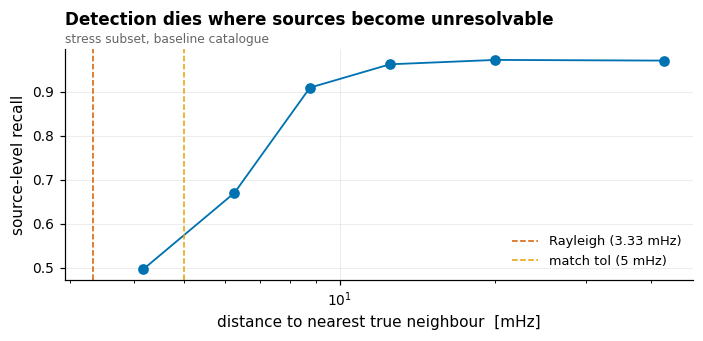

In [23]:
# --- A3: where detection dies: recall vs true source separation ------------
edges = np.array([0, 2, 3.33, 5, 7.5, 10, 15, 25, 60]) * 1e-3   # Hz
det = {e: [0, 0] for e in range(len(edges) - 1)}
for i in FULL:
    truth = TRUTHS["stress"][int(i)]
    pairs, _, un_t = match_catalogue(baseline_catalogue(int(i)), truth)
    matched_j = {j for _, j in pairs}
    for j in range(len(truth)):
        others = np.abs(truth[:, 2] - truth[j, 2])
        sep = np.min(others[others > 0]) if len(truth) > 1 else np.inf
        b = np.searchsorted(edges, min(sep, edges[-1] - 1e-9)) - 1
        det[b][0] += int(j in matched_j)
        det[b][1] += 1

fig, ax = plt.subplots(figsize=(6.5, 3.2))
xs = 1e3 * (edges[:-1] + edges[1:]) / 2
ys = [det[b][0] / det[b][1] if det[b][1] else np.nan
      for b in range(len(edges) - 1)]
ax.plot(xs, ys, marker="o", color=C["pred"])
ax.axvline(3.33, color=C["truth"], ls="--", lw=1, label="Rayleigh (3.33 mHz)")
ax.axvline(5.0, color=C["gold"], ls="--", lw=1, label="match tol (5 mHz)")
ax.set_xscale("log")
ax.set_xlabel("distance to nearest true neighbour  [mHz]")
ax.set_ylabel("source-level recall")
ax.legend()
title2(ax, "Detection dies where sources become unresolvable",
       "stress subset, baseline catalogue")
plt.tight_layout()